## This script gets the sequences of ref and alt variants from the design file

### Top results checking for TFs
- identify the sequences without adapters from fasta file (header.str.contains('id von hit'))
- split the found header by "_fwd" and get the first part
- replace ALT_ with REF_ and get the sequence as reference

In [2]:
import pandas as pd
import yaml
import os

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf

# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [3]:
design_fa = hf.fasta_to_dataframe(config['files']['final_design']['design_fasta'])
variant_table = pd.read_csv(config['files']['final_design']['variant_table'], sep="\t")

In [4]:
high_effect_variants = pd.read_csv('/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/high_effect_variants_resequencing.tsv', sep="\t")

FileNotFoundError: [Errno 2] No such file or directory: '/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/high_effect_variants_resequencing.tsv'

In [37]:
top_2 = high_effect_variants.head(2)
bottom_2 = high_effect_variants.tail(2)
interesting_variants = pd.concat([top_2, bottom_2])

In [31]:
def write_ref_alt_sequences(sequence_df, output_path, header_cols, sequence_cols):
    """
    Write the fasta file with the header and sequence of the alterantive and reference sequences
    """
    with open(output_path, 'w') as f:
        for index, row in sequence_df.iterrows():
            f.write('>' + row[header_cols[0]] + '\n' + row[sequence_cols[0]] + '\n')
            f.write('>' + row[header_cols[1]] + '\n' + row[sequence_cols[1]] + '\n')
    return True


In [42]:
ids = interesting_variants['Variant_without_group'].to_list()
print(ids)
# replace | with \| for using contains

# get row in design fasta
escaped_ids = []
for elem in ids:
    print(elem)
    escaped_ids.append(elem.replace('|', '\|'))

alternative_sequences = design_fa.loc[design_fa['header'].str.contains('|'.join(escaped_ids))]
alternative_sequences.columns = ['ALT_ID', 'alt_sequence']

# # find references with variant table
alt_and_ref_id = alternative_sequences.merge(variant_table, on='ALT_ID', how='left')

# # get sequences for references as well
alt_and_ref_sequences = alt_and_ref_id.merge(design_fa, left_on='REF_ID', right_on='header')
alt_and_ref_sequences.rename(columns={'sequence': 'ref_sequence'}, inplace=True)
alt_and_ref_sequences
# remove adapters of coloms containing sequence
alt_and_ref_sequences['ref_sequence'] = alt_and_ref_sequences['ref_sequence'].str[15:285]
alt_and_ref_sequences['alt_sequence'] = alt_and_ref_sequences['alt_sequence'].str[15:285]

output_file = '/data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/IGVF_Y1_design/projects/80K_MPRA/variant_tf_search/top_bottom_2_variants.fa'
output_file = '/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/test_alt_ref_output.fa'
write_ref_alt_sequences(alt_and_ref_sequences, output_path=output_file, header_cols=['ALT_ID', 'REF_ID'], sequence_cols=['alt_sequence', 'ref_sequence'])

['TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T', 'TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G', 'PNKP|ENSG00000039650.12|EH38E3313885|19-49907159-A-C', 'TLK2|ENSG00000146872.19|EH38E1876701|17-62454069-C-A']
TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T
TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G
PNKP|ENSG00000039650.12|EH38E3313885|19-49907159-A-C
TLK2|ENSG00000146872.19|EH38E1876701|17-62454069-C-A


True

### Overlap with E2G predictions: 
- embryonic male neuronal stem cells encode (H1): `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/full_predictions/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_full_predictions.tsv.gz`
- bedpe: `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz`

In [1]:
# read bedpe file as tsv
bedpe_e2g_thresholded = pd.read_csv('/home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_analysis/notebooks/high_effect_variants_resequencing.bedpe', sep="\t")
bedpe_e2g_thresholded

NameError: name 'pd' is not defined

### Using NN + tfmodisco to find contribution maps (exported from tfmodisco) and align to the sequences with FIMO
- Thorben scirpts: `/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/pipelineCommands/pipeline_jointPost_HASMC_vs_HASMC_chol_JASPAR.sh`
- Thorben scripts: Modeltraining and tf modisco: `/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/model_train_eval_interpretation`

### Find TFBS with FIMO in elements
- read element result from barcode MPRAlm 
  - Note: currently 27.07: problems with element analysis (statistical test treat) => only scrambled sequences results

In [6]:
# read element files in config creating, element_analysis_mk_scrambled_vs_tested_no_alt
element_scrambled_vs_tested = pd.read_csv(config['files']['creating']['element_analysis_mk_scrambled_vs_tested_no_alt'], sep="\t")
element_scrambled_vs_tested

element_scrambled_vs_tested['is_significant'] = element_scrambled_vs_tested['adj.P.Val'] < 0.05
element_scrambled_vs_tested['positive_logFC'] = element_scrambled_vs_tested['logFC'] > 0
element_scrambled_vs_tested['negative_logFC'] = element_scrambled_vs_tested['logFC'] < 0

In [7]:
# generate overview of the number of significant results
group= 'scrambled_MK'
print(f'Significant means significantly different to {group}')
# total number of table
print(f'Size of the element table: {element_scrambled_vs_tested.shape[0]}')
# number of significant results
significant_tested_elements = element_scrambled_vs_tested[element_scrambled_vs_tested["is_significant"]]
print(f'Number of significant results: {significant_tested_elements.shape[0]}')

# number of signifianct reguls with positive effect
print(f'Number of significant results with positive effect: {significant_tested_elements[significant_tested_elements["positive_logFC"]].shape[0]}')
# number of significant reguls with negative effect
print(f'Number of significant results with negative effect: {significant_tested_elements[significant_tested_elements["negative_logFC"]].shape[0]}')

Size of the element table: 23203
Number of significant results: 886
Number of significant results with positive effect: 600
Number of significant results with positive effect: 286


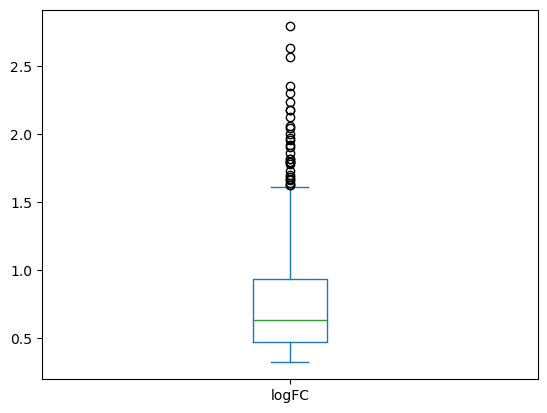

count    286.000000
mean      -1.527608
std        0.177583
min       -2.266782
25%       -1.627323
50%       -1.499437
75%       -1.401426
max       -1.214374
Name: logFC, dtype: float64

In [17]:
# investigate logFC distribution (range for positive and negative effect)
positive_logFC_elements = significant_tested_elements[significant_tested_elements["positive_logFC"]]

positive_logFC_elements['logFC'].describe() # 0.319880 - 2.79
# boxplot:
positive_logFC_elements['logFC'].plot(kind='box')
plt.show()

# compare negaitve logFC and positive logFC boxplot
negative_logFC_elements = significant_tested_elements[significant_tested_elements["negative_logFC"]]
negative_logFC_elements['logFC'].describe() # -2.266782 - -1.214374

# negative_logFC_elements['logFC'].plot(kind='box')
# plt.show()


In [20]:
significant_tested_elements.columns

Index(['logFC', 'AveExpr', 't', 'P.Value', 'adj.P.Val', 'variant_id',
       'is_significant', 'positive_logFC', 'negative_logFC'],
      dtype='object')

In [35]:
# get sequence of ids:
metadata_file = pd.read_csv(config['files']['creating']['region_metadata_table_local_tested_juli'], sep="\t", low_memory=False)
metadata_file
metadata_only_sequence = metadata_file[['name', 'sequence']]

# left join
significant_with_sequences = significant_tested_elements.merge(metadata_only_sequence, left_on='variant_id', right_on='name')
print('sanity check: no sequence na? ', significant_with_sequences['sequence'].isna().sum())
# only significant results: write to fasta
element_group_name = 'element_scrambled_vs_tested_no_alt'
output_directory = config['files']['creating']['element_motif_analysis_output_directory']
output_path = os.path.join(output_directory, f'significant_{element_group_name}.fa')
# new column of names without group
significant_with_sequences['no_lable_name'] = significant_with_sequences['name'].str.split(':').str[1]
hf.write_fasta(significant_with_sequences, output_path=output_path, header=['no_lable_name', 'sequence'])


sanity check: no sequence na?  0


True

use fimo: 
activate environment
```bash
coa meme;
cd /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search;
fimo --max-stored-scores 1000000 --o fimo_element_scrambled_mk_signficant /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/significant_element_scrambled_vs_tested_no_alt.fa ;
```
in directory: fimo_element_scrambled_mk_significant: fimo.tsv: /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_element_scrambled_mk_signficant/fimo.tsv
- Fimo:
- q-value for significants (0.01)
  - need to hold all previous matches in memory (default 100000) 
    - controlable: `--max-stored-scores` 
- random hits:
    - 4**8 (8-mere)
    - considering 1000k sequences (+ and minus strand): 8-mers so random hit pro sequence is 2*(993/4**8)

- use   
- motif set: /data/cephfs-2/unmirrored/groups/ag-kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant.meme


In [40]:
# read file with comments #
fimo_results = pd.read_csv('/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_element_scrambled_mk_signficant/fimo.tsv', sep="\t", comment='#')
# fimo_results = pd.read_csv('/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_element_scrambled_mk_signficant_with_label/fimo.tsv', sep="\t", comment='#')
fimo_results

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
0,ZN441.H12CORE.1.P.C,NaN,KMT2E|ENSG00000005483.23|EH38E2578210_fwd_tile1-1,20,50,-,51.25510,2.590000e-17,1.230000e-11,TTGAGACAGAGTCTCGCTCTGTCGCCCAGGC
1,ZN441.H12CORE.1.P.C,NaN,REF_ANKRD11|ENSG00000167522.17|EH38E3200802_re...,193,223,+,47.07140,5.480000e-16,1.300000e-10,CTGAGACAGAGTCTCGCTCTGTCGCCCAGGC
2,ZN560.H12CORE.0.P.C,NaN,REF_GRIN2A|ENSG00000183454.18|EH38E3167374_rev...,101,123,-,41.68310,5.240000e-15,8.440000e-10,CCACTGCACTCCAGCCTGGGCGA
3,ZN560.H12CORE.0.P.C,NaN,REF_ANKRD11|ENSG00000167522.17|EH38E3200802_re...,214,236,-,41.68310,5.240000e-15,8.440000e-10,CCACTGCACTCCAGCCTGGGCGA
4,ZN560.H12CORE.0.P.C,NaN,DTNA|ENSG00000134769.23|EH38E3263259_fwd_tile1-1,257,279,+,41.68310,5.240000e-15,8.440000e-10,CCACTGCACTCCAGCCTGGGCGA
...,...,...,...,...,...,...,...,...,...,...
63261,RARG.H12CORE.0.P.B,NaN,REF_CARD11|ENSG00000198286.11|EH38E2530090_rev...,30,47,+,10.17740,1.000000e-04,5.570000e-01,TCCAGGCCACCATCACCT
63262,PKNX1.H12CORE.1.P.B,NaN,PLCB1|ENSG00000182621.18|EH38E2096594_fwd_tile1-1,53,63,-,10.50460,1.000000e-04,5.890000e-01,TCATTGACAGC
63263,ZFP14.H12CORE.0.P.C,NaN,REF_RFX3|ENSG00000080298.16|EH38E3872055_rev_t...,53,70,+,8.33333,1.000000e-04,3.240000e-01,GCTGTCCTCTCTCTCTCC
63264,ZFP14.H12CORE.0.P.C,NaN,REF_ANKRD11|ENSG00000167522.17|EH38E3200802_re...,60,77,+,8.33333,1.000000e-04,3.240000e-01,TCCTGCCTTGGCCTCCCA


investigate the results:
- number of unique matched motifs 
- number of unique matched sequences
- number of matches with q-value 0.01
- number of matches with p-value 0.01


In [67]:
# print number of all fimo findings
print(f'Number of all fimo findings: {fimo_results.shape[0]}') # 63266

# findings in different sequences
fimo_results['sequence_name'].value_counts()
print(f'Hits in {fimo_results["sequence_name"].nunique()} different sequences') # 886

# print number of different motifs:
print(f'Number of different motifs: {fimo_results["motif_id"].nunique()}') # 523
# print number of significant results
# # according to p-value all hits are significant
# significant_fimo_results_pvalue = fimo_results[fimo_results['p-value'] < q_value_threshold]
# print(f'Number of significant results (p-value < 0.01): {significant_fimo_results_pvalue.shape[0]}') # 63266
# q-value:
print('-------\tinvestigating significant results: ')
q_value_threshold = 0.01
significant_fimo_results = fimo_results[fimo_results['q-value'] < q_value_threshold]
print(f'Number of significant results: {significant_fimo_results.shape[0]}') # 1255
significant_fimo_results
# findings in different sequences
significant_fimo_results['sequence_name'].value_counts()
print(f'Hits in {significant_fimo_results["sequence_name"].nunique()} different sequences') # 318

# print number of different motifs:
print(f'Number of different motifs: {significant_fimo_results["motif_id"].nunique()}') # 69

# sort by q-value and show the top 10
significant_fimo_results.sort_values(by='q-value').head(10)
significant_fimo_results.sort_values(by='q-value').to_csv('/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/significant_fimo_results.tsv', sep="\t", index=False)
# are sequences overrepresented with the high confidence motifs?
# significant_fimo_results.sort_values(by='q-value').head(50)['sequence_name'].value_counts().head(50)
# significant_fimo_results['sequence_name'].value_counts().head(50)

# trick: from ultra need to ask

Number of all fimo findings: 63266
Hits in 886 different sequences
Number of different motifs: 523
-------	investigating significant results: 
Number of significant results: 1255
Hits in 318 different sequences
Number of different motifs: 69


In [ ]:
# write sequences for fimo in fasta file
def plot_top_bottom(df, cell_type, top=250, bottom=250):
    # sort by absolute log2 values
    df = df.reindex(df['log2_'+cell_type].abs().sort_values(ascending=False).index)

    # trim sequences by removing 15 bases from the start and end
    df['sequence'] = df['sequence'].str[15:-15]
    # take top and bottom
    top_df = df.head(top)
    bottom_df = df.tail(bottom)
    #
    write_fasta(top_df, '/data/gpfs-1/users/dashpm_c/work/projects/gene_expression_mpra/data/log2_'+cell_type+'_top_'+str(top)+'.fa')
    write_fasta(bottom_df, '/data/gpfs-1/users/dashpm_c/work/projects/gene_expression_mpra/data/log2_'+cell_type+'_bottom_'+str(bottom)+'.fa')

    return print("done!")

Make repressor and activator sequences:
- sort list of significant_with_sequences and write down top and bottom 100 sequences

In [63]:
# hf.write_fasta(significant_with_sequences, output_path=output_path, header=['no_lable_name', 'sequence'])
number_top_bottom = 100
output_directory = config['files']['creating']['element_motif_analysis_output_directory']
output_path_top100 = os.path.join(output_directory, f'intput_motif_enrichment_significant_top_{number_top_bottom}_{element_group_name}.fa')
output_path_tail100 = os.path.join(output_directory, f'intput_motif_enrichment_significant_bottom_{number_top_bottom}_{element_group_name}.fa')
top_100_significant_elements = significant_with_sequences.sort_values(by='logFC').head(number_top_bottom)
tail_100_significant_elements = significant_with_sequences.sort_values(by='logFC').tail(number_top_bottom)

# write to fasta
hf.write_fasta(top_100_significant_elements, output_path=output_path_top100, header=['no_lable_name', 'sequence'])
hf.write_fasta(tail_100_significant_elements, output_path=output_path_tail100, header=['no_lable_name', 'sequence'])


True

Use AME: Analysis of Motif Enrichment
```bash
coa meme;
cd /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search;
ame --verbose 1 --control /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/element_scrambled_vs_tested_no_alt.fa /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_element_scrambled_mk_signficant/fimo.tsv /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/resources/H12CORE.meme;
```